In [14]:
import sys
# Ajouter l'environnement virtuel aifes_env au chemin de recherche de Python
sys.path.append('/content/aifes_env/lib/python3.9/site-packages')

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sklearn.model_selection
import subprocess, tqdm, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
print(tf.__version__)
from aifes import keras2aifes

2.13.0


In [15]:
GPU_ID = 0
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[GPU_ID], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[GPU_ID], True)
    except RuntimeError as e:
        print(e)

In [16]:
def imshow(img, title):
    plt.imshow(img, cmap = "binary")
    plt.title(str(title))
    plt.show()

def plot_value_array(i, predictions_array, true_label, num_classes):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(num_classes))
    plt.yticks([])
    thisplot = plt.bar(range(num_classes), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                    100*np.max(predictions_array),
                                    true_label),
                                    color=color)

def plot_n_images(n, x, y):
    num_cols = 4
    assert (n % num_cols == 0)
    num_rows = n // num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(n):
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plt.imshow(x[i])
        plt.title(str(y[i]))
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plt.tight_layout()
    plt.show()

def print_prediction(n, x_test, y_test, predictions, num_classes = 10):
    num_cols = 4
    assert (n % num_cols == 0)
    num_rows = n // num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(n):
        ind = np.random.randint(0, x_test.shape[0]-1)
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_image(ind, predictions[ind], y_test, x_test)
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plot_value_array(ind, predictions[ind], y_test, num_classes)
    plt.tight_layout()
    plt.show()

def plot_accuracy_loss(history, epochs, batch_size):
    stepX, stepY = 10, 0.025
    fig, axs = plt.subplots(2)
    axs[0].set_xticks(np.arange(0, epochs+stepX, stepX))
    axs[0].set_yticks(np.arange(0., 1.+stepY, stepY))
    axs[0].plot(history.epoch, history.history["accuracy"], 'g', label='Training accuracy')
    axs[0].plot(history.epoch, history.history["val_accuracy"], 'r', label='Validation accuracy')
    axs[0].set_title('Training & validation accuracy (batch_size = ' + str(batch_size) + ")")
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')

    axs[1].set_xticks(np.arange(0, epochs+stepX, stepX))
    axs[1].plot(history.epoch, history.history["loss"], 'g', label='Training loss')
    axs[1].plot(history.epoch, history.history["val_loss"], 'r', label='Validation loss')
    axs[1].set_title('Training & validation loss (batch_size = ' + str(batch_size) + ")")
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    fig.legend()
    plt.show()

def plot_dataset_balance(y, name):
    size           = y.shape[0]
    labels, counts = np.unique(y, return_counts = True)
    print("Minimum label occurence:", np.min(counts))
    plt.bar(labels, counts)
    plt.title(name + " set balance")
    plt.xlabel("Classes")
    plt.ylabel("Frequency")
    plt.show()


In [17]:
def balance_dataset(x, y):
    number_classes = np.unique(y).shape[0]
    min_occurence  = np.min(np.unique(y, return_counts = True)[1])
    x_bal, y_bal   = [], []
    for c in tqdm.trange(number_classes): # For every class
        c_idx = np.where(y == c)[0] # Filter data per class
        x_bal.append(x[c_idx][:min_occurence]) # Only keep the first min_occurence images of each class
        y_bal.append(y[c_idx][:min_occurence])
    x_bal = np.concatenate(x_bal)
    y_bal = np.concatenate(y_bal)
    return x_bal, y_bal

def to_categorical(y):
    return np.eye(np.unique(y).shape[0])[y]

def hwc_to_chw(x):
    return np.transpose(x, (0, 3, 1, 2))

def chw_to_hwc(x):
    return np.transpose(x, (0, 2, 3, 1))

def normalize_dataset(x):
    return (x / 255) - 0.5

def flatten_dataset(x):
    return np.reshape(x, (x.shape[0], np.prod(x.shape[1:])))

# MNIST dataset loading/processing

Training set
(60000, 28, 28)
Minimum label occurence: 5421


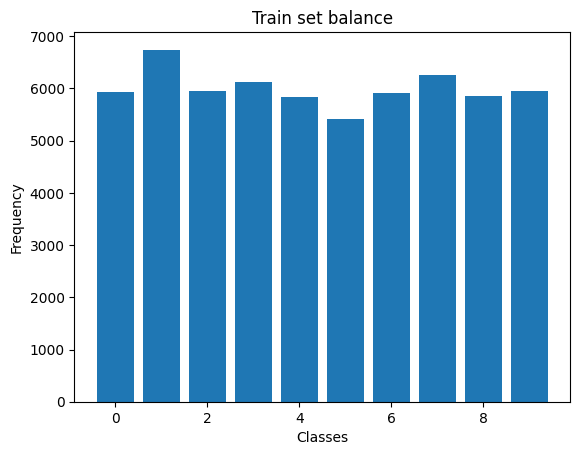

Testing set
(10000, 28, 28)
Minimum label occurence: 892


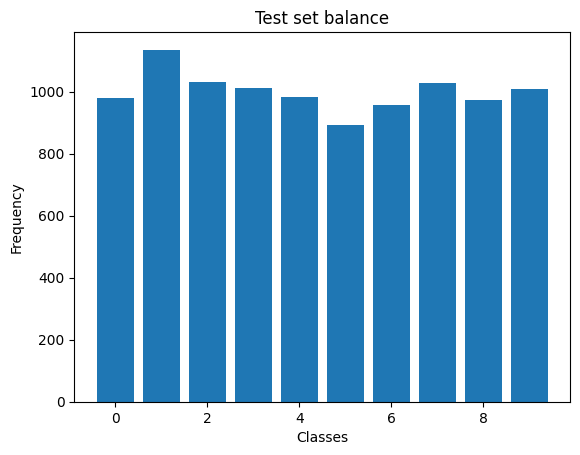

In [18]:
H, W, C     = 28, 28, 1
NUM_CLASSES = 10

# Building MNIST dataset
(x_mnist_train, y_mnist_train), (x_mnist_test, y_mnist_test) = tf.keras.datasets.mnist.load_data()

# Normalize dataset
x_mnist_train = normalize_dataset(x_mnist_train)
x_mnist_test = normalize_dataset(x_mnist_test)

print("Training set")
print(x_mnist_train.shape)
plot_dataset_balance(y_mnist_train, "Train")

print("Testing set")
print(x_mnist_test.shape)
plot_dataset_balance(y_mnist_test, "Test")

Balanced training set


100%|██████████| 10/10 [00:00<00:00, 81.01it/s]


(54210, 28, 28)
Minimum label occurence: 5421


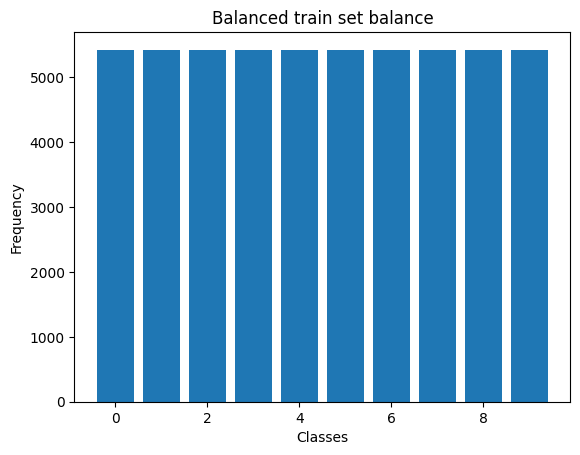

Balaned testing set


100%|██████████| 10/10 [00:00<00:00, 515.14it/s]

(8920, 28, 28)
Minimum label occurence: 892


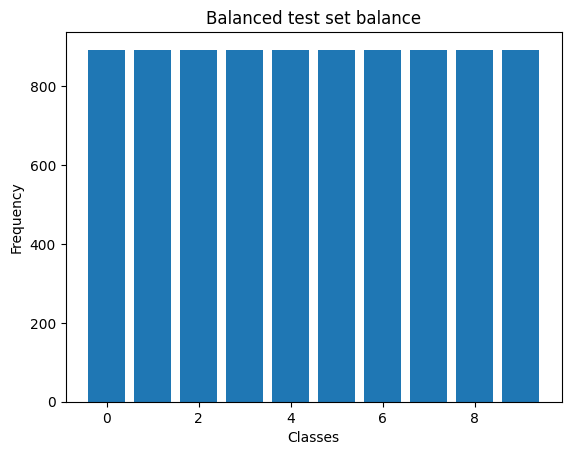

In [19]:
print("Balanced training set")
x_mnist_train, y_mnist_train = balance_dataset(x_mnist_train, y_mnist_train)
print(x_mnist_train.shape)
plot_dataset_balance(y_mnist_train, "Balanced train")

print("Balaned testing set")
x_mnist_test, y_mnist_test = balance_dataset(x_mnist_test, y_mnist_test)
print(x_mnist_test.shape)
plot_dataset_balance(y_mnist_test, "Balanced test")

# Shuffle train set
p = np.random.permutation(y_mnist_train.shape[0])
x_mnist_train = x_mnist_train[p]
y_mnist_train = y_mnist_train[p]

# Shuffle test set
p = np.random.permutation(y_mnist_test.shape[0])
x_mnist_test = x_mnist_test[p]
y_mnist_test = y_mnist_test[p]

C:\Users\azert\AppData\Local\Temp\ipykernel_37744\2830659759.py:46: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(num_rows, 2*num_cols, 2*i+2)


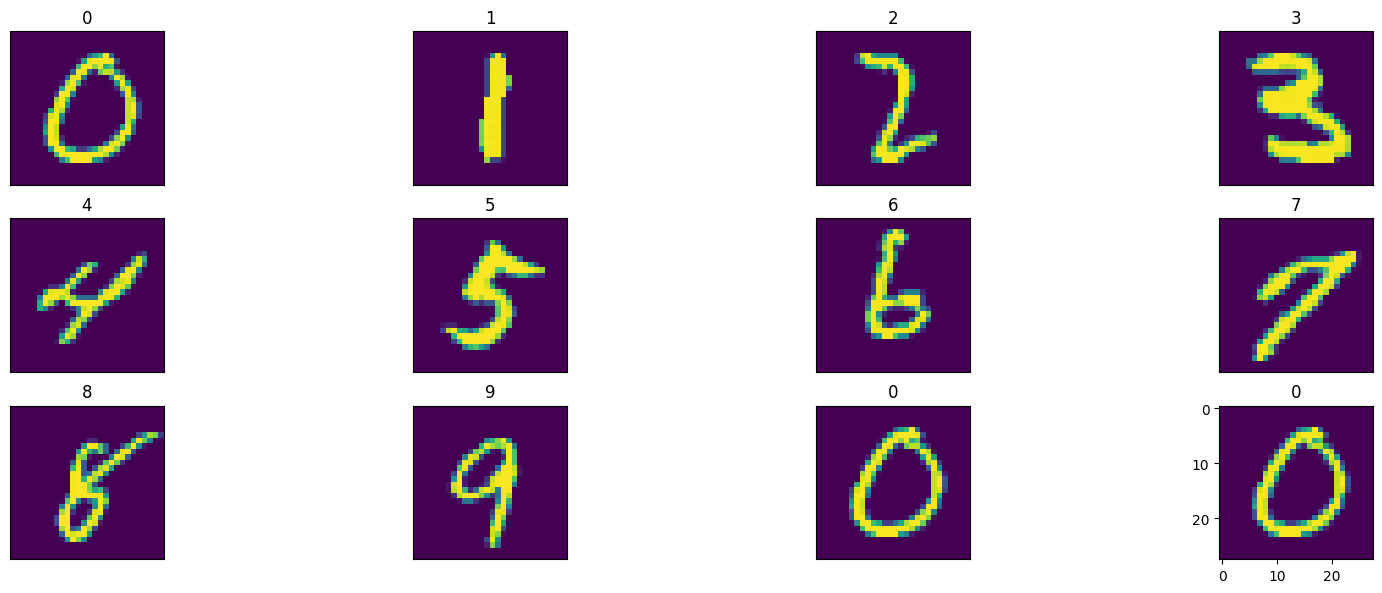

In [20]:
# Print an image of each class
x = np.array([x_mnist_train[np.where(y_mnist_train == i)[0][0]] for i in range(NUM_CLASSES)] + [x_mnist_train[0]]*(NUM_CLASSES%4))
y = np.array([y_mnist_train[np.where(y_mnist_train == i)[0][0]] for i in range(NUM_CLASSES)] + [y_mnist_train[0]]*(NUM_CLASSES%4))
plot_n_images(x.shape[0], x, y)

# MNIST finetuning

In [21]:
EPOCHS        = 20#50
LEARNING_RATE = 1e-3
BATCH_SIZE    = 128#256
LOSS_FUNCTION = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False)
OPTIMIZER     = tf.keras.optimizers.Adam(LEARNING_RATE)

In [33]:
model_mnist = tf.keras.models.Sequential([
    tf.keras.layers.Input((C*H*W,)),
    tf.keras.layers.Dense(512, activation = "relu"),
    #tf.keras.layers.Dense(256, activation = "relu"),
    #tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(64, activation = "relu"),
    tf.keras.layers.Dense(32, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])
model_mnist.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_42 (Dense)            (None, 512)               401920    
                                                                 
 dense_43 (Dense)            (None, 64)                32832     
                                                                 
 dense_44 (Dense)            (None, 32)                2080      
                                                                 
 dense_45 (Dense)            (None, 10)                330       
                                                                 
Total params: 437162 (1.67 MB)
Trainable params: 437162 (1.67 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
model_mnist.compile(
    optimizer = OPTIMIZER,
    loss      = LOSS_FUNCTION,
    metrics   = ["accuracy"]
)

Epoch 1/20
424/424 [==============================] - 5s 10ms/step - loss: 0.4460 - accuracy: 0.8624 - val_loss: 0.2170 - val_accuracy: 0.9334
Epoch 2/20
424/424 [==============================] - 4s 9ms/step - loss: 0.1816 - accuracy: 0.9445 - val_loss: 0.1441 - val_accuracy: 0.9574
Epoch 3/20
424/424 [==============================] - 4s 9ms/step - loss: 0.1283 - accuracy: 0.9606 - val_loss: 0.1075 - val_accuracy: 0.9677
Epoch 4/20
424/424 [==============================] - 4s 9ms/step - loss: 0.0995 - accuracy: 0.9693 - val_loss: 0.0995 - val_accuracy: 0.9677
Epoch 5/20
424/424 [==============================] - 4s 9ms/step - loss: 0.0830 - accuracy: 0.9742 - val_loss: 0.0856 - val_accuracy: 0.9723
Epoch 6/20
424/424 [==============================] - 4s 8ms/step - loss: 0.0719 - accuracy: 0.9772 - val_loss: 0.0914 - val_accuracy: 0.9719
Epoch 7/20
424/424 [==============================] - 4s 9ms/step - loss: 0.0645 - accuracy: 0.9795 - val_loss: 0.0901 - val_accuracy: 0.9716
Epoch

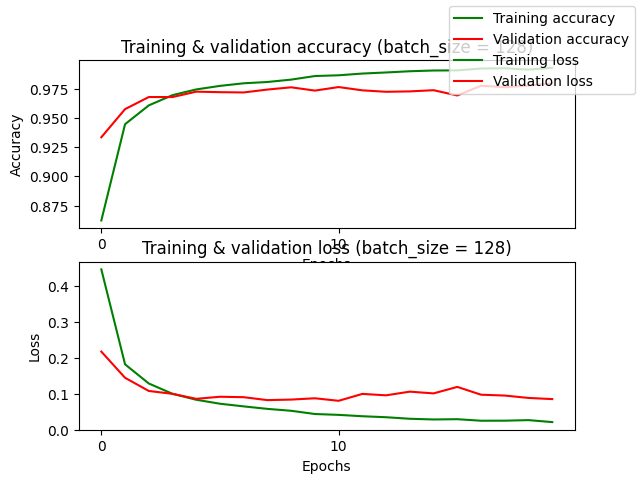

In [35]:
x_mnist_train = flatten_dataset(x_mnist_train)
#y_mnist_train = to_categorical(y_mnist_train)

x_mnist_test = flatten_dataset(x_mnist_test)
#y_mnist_test = to_categorical(y_mnist_test)

history_mnist = model_mnist.fit(
    x_mnist_train,
    y_mnist_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_data  = (x_mnist_test, y_mnist_test)
)

plot_accuracy_loss(history_mnist, EPOCHS, BATCH_SIZE)

In [36]:
print("Evaluation on train set : ")
model_mnist.evaluate(x_mnist_train, y_mnist_train, verbose=2)

print("Evaluation on test set : ")
model_mnist.evaluate(x_mnist_test, y_mnist_test, verbose=2)

Evaluation on train set : 
1695/1695 - 4s - loss: 0.0122 - accuracy: 0.9961 - 4s/epoch - 2ms/step
Evaluation on test set : 
279/279 - 1s - loss: 0.0848 - accuracy: 0.9795 - 574ms/epoch - 2ms/step


[0.0848151221871376, 0.9794843196868896]

279/279 [==============================] - 1s 2ms/step


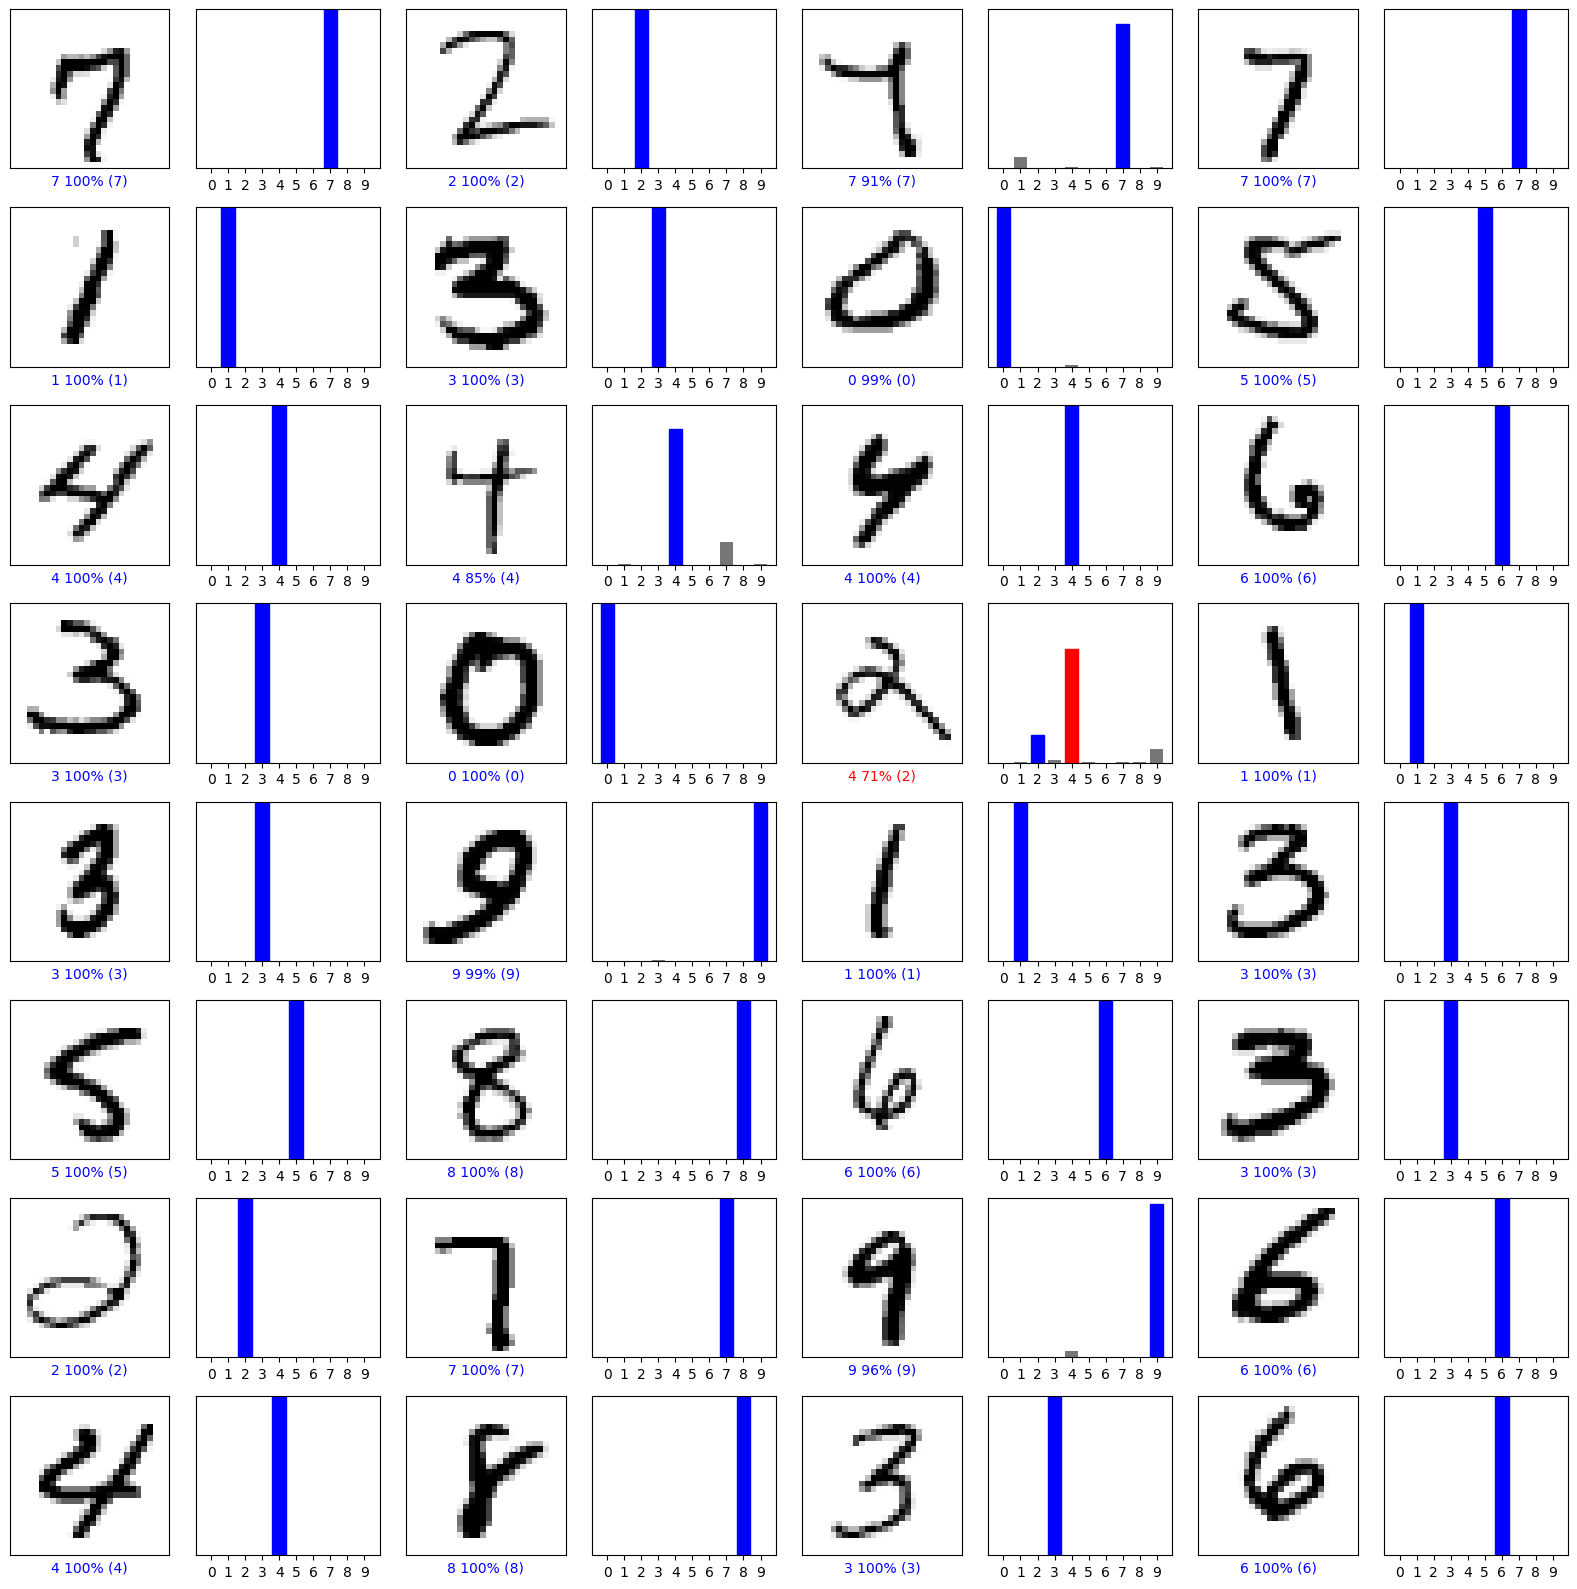

In [37]:
predictions = model_mnist.predict(x_mnist_test)
print_prediction(32, x_mnist_test.reshape((-1, H, W))+0.5, y_mnist_test, predictions, num_classes = NUM_CLASSES)

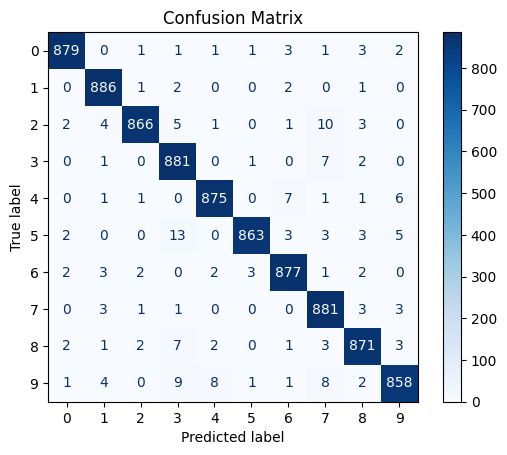

In [38]:
cm = confusion_matrix(y_mnist_test, np.argmax(predictions, axis = 1))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [str(i) for i in range(NUM_CLASSES)])
disp.plot(cmap = 'Blues')
plt.title("Confusion Matrix")
plt.show()

In [39]:
# Save model and its metadata
os.makedirs("models", exist_ok=True)
model_name = "models/5dense-mnist-10class-finetuned"
model_mnist.save(model_name + ".h5")

# Convertion en format .tflite car le .h5 me rencoie des erreurs
converter = tf.lite.TFLiteConverter.from_keras_model(model_mnist)
tflite_model = converter.convert()

tflite_path = model_name + ".tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

with open(model_name + "-history.json", "w") as f:
    json.dump(history_mnist.history, f)


C:\Users\azert\anaconda3\envs\py38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


INFO:tensorflow:Assets written to: C:\Users\azert\AppData\Local\Temp\tmpq3efsot2\assets


INFO:tensorflow:Assets written to: C:\Users\azert\AppData\Local\Temp\tmpq3efsot2\assets


In [40]:
# Reload model and its metadata
model_mnist_name = "models/5dense-mnist-10class-finetuned"
model_mnist = tf.keras.models.load_model(model_mnist_name + ".h5")
class History:
    def __init__(self):
        self.history = {}
        self.epoch   = 0
history_mnist = History()
with open(model_mnist_name + "-history.json", 'r') as f:
    history_mnist.history = json.load(f)
history_mnist.epoch       = list(range(len(history_mnist.history["loss"])))

# Model deployment using AIfES-Converter

In [41]:
NUM_CLASSES = 10
NUM_PICTURES = 10
x_mnist_train = x_mnist_train[:NUM_PICTURES]
x_mnist_test = x_mnist_test[:NUM_PICTURES]
y_mnist_train = y_mnist_train[:NUM_PICTURES]
y_mnist_test = y_mnist_test[:NUM_PICTURES]

In [42]:
BASE_PATH     = "."
MODEL          = model_mnist
MODEL_TYPE     = "mlp"
DATASET_NAME   = "mnist"
LOSS_NAME      = "crossentropy"
OPTIMIZER_NAME = "adam"#"sgd"
FROZEN_LAYERS = [False, False, False, False, False]
WITH_WEIGHTS = True

CONVERT_DATASET = False

frozen_layers  = FROZEN_LAYERS
with_weights   = WITH_WEIGHTS
train_set_size = x_mnist_train.shape[0]
test_set_size  = x_mnist_test.shape[0]
test_name      = DATASET_NAME + "-" + MODEL_TYPE + "-" + str(len(MODEL.layers)) + "layers" + "-" + str(frozen_layers.count(True)) + "frozen" + "-" + ("pretrained" if with_weights else "untrained") + "-" + LOSS_NAME + "-" + OPTIMIZER_NAME

#Création du dossier
output_path = "./f32/mnist-mlp-5layers-0frozen-pretrained-crossentropy-adam"
os.makedirs(output_path, exist_ok=True)

# F32 deployment
keras2aifes.convert_to_fnn_f32(
    MODEL,
    BASE_PATH + "/f32/" + test_name
)

"""keras2aifes.convert_to_fnn_f32(
    MODEL,
    BASE_PATH + "/f32/" + test_name,
    train_set_size,
    test_set_size,
    with_weights = with_weights,
    loss = LOSS_NAME,
    optimizer = OPTIMIZER_NAME,
    with_frozen_layers = False,
    frozen_layers = frozen_layers
)"""
if(CONVERT_DATASET):
    dataset2flatbuffer.dataset2flatbuffer(
        BASE_PATH + "/dataset/" + DATASET_NAME + "-f32",
        32,
        x_mnist_train,
        y_mnist_train,
        x_mnist_test,
        y_mnist_test,
        num_classes = NUM_CLASSES
    )


In [49]:
dataset = np.load("data/MNIST_xtest_NN_C2_16_10.npy")

# Selection image
img = dataset[4]

# 3. Aplatir cette image spécifique pour obtenir 784 pixels
img_flat = img.flatten()

# Vérification de sécurité
if len(img_flat) != 784:
    print(f"Attention: l'image fait {len(img_flat)} pixels au lieu de 784.")

# L'image est déjà divisée par 255, on a juste besoin de la centrer
img_flat = img_flat - 0.5

# Générer le code C
c_code = "float input_data[784] = {\n    "
c_code += ", ".join([f"{val:.4f}f" for val in img_flat])
c_code += "\n};"

print(c_code)

float input_data[784] = {
    -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, -0.5000f, 

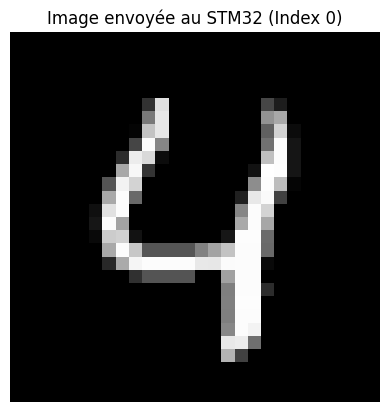

In [50]:
# Reformater le tableau 1D de 784 valeurs en une grille 2D de 28x28 pixels
img_2d = img.reshape(28, 28)

# Afficher l'image en niveaux de gris
plt.imshow(img_2d, cmap='gray')
plt.title("Image envoyée au STM32 (Index 0)")
plt.axis('off')
plt.show()